## GBmap: Spearman Correlation of MP Signatures (healthy vs. diseased)

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import seaborn as sns
import matplotlib.pyplot as plt
import os

### Load Data

In [2]:
BASE = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune"
OUT_DIR = f"{BASE}/results/09_HIHAtlas"

In [3]:
genes_gbmap = pd.read_csv("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/04_NMF_GSEAonHGNC/04_3_nmf_all_gsea_c7/genes.csv")
genes_hiha = pd.read_csv("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/09_HIHAtlas/09_03_nmf_downsampled/genes.csv")

In [6]:
SELECTED_MPS = ["MP1", "MP2", "MP7", "MP8", "MP9", "MP11", "MP14", "MP15", "MP19", "MP20"]
genes_gbmap_selected = genes_gbmap[genes_gbmap["mp"].isin(SELECTED_MPS)]

In [4]:
gbmap_adata = sc.read_h5ad(f"{BASE}/data/01_extGBmap/immune_cells_gbmap_TICAannot_gpu.h5ad")

### load MP Scores of selected diseased MPs of GBmap

In [20]:
mp_scores_native = pd.read_csv(f"{BASE}/results/04_NMF_GSEAonHGNC/04_3_nmf_all_gsea_c7/mp_scores.csv", index_col=0)

In [23]:
common_barcodes = mp_scores_native.index.intersection(gbmap_adata.obs_names)
print(f"{len(common_barcodes)} / {gbmap_adata.n_obs} matched")

mp_scores_aligned = mp_scores_native.reindex(gbmap_adata.obs_names)

native_score_cols = [f"{mp}_score" for mp in SELECTED_MPS]
for col in native_score_cols:
    gbmap_adata.obs[col] = mp_scores_aligned[col].values

633710 / 633710 matched


### Score healthy MPs on GBmap genes

In [24]:
def score_mps(adata, genes_df, prefix="", min_overlap=0.5):
    overlap_records = []
    for mp in genes_df["mp"].unique():
        mp_genes = genes_df.loc[genes_df["mp"] == mp, "gene"].tolist()
        n_present = sum(g in adata.var_names for g in mp_genes)
        overlap_records.append({
            "mp": mp, "n_total_genes": len(mp_genes),
            "n_present_genes": n_present,
            "pct_overlap": n_present / len(mp_genes) if mp_genes else 0.0,
        })
    overlap_df = pd.DataFrame(overlap_records).sort_values("pct_overlap")
    print(overlap_df)

    mps_scored = overlap_df.loc[overlap_df["pct_overlap"] >= min_overlap, "mp"].tolist()

    for mp in mps_scored:
        mp_df = genes_df[genes_df["mp"] == mp]
        gene_weights = dict(zip(mp_df["gene"], mp_df["score"]))
        genes_present = [g for g in gene_weights if g in adata.var_names]
        weights = np.array([gene_weights[g] for g in genes_present])
        gene_idx = [adata.var_names.get_loc(g) for g in genes_present]

        X_sub = adata[:, gene_idx].X
        if sp.issparse(X_sub):
            X_sub = X_sub.toarray()

        weighted_score = (X_sub * weights).sum(axis=1) / weights.sum()
        adata.obs[f"{prefix}{mp}_score"] = np.asarray(weighted_score).flatten()

    return mps_scored

In [25]:
hiha_mps_scored = score_mps(gbmap_adata, genes_hiha, prefix="HIHA_")

    mp  n_total_genes  n_present_genes  pct_overlap
3  MP4             57               54     0.947368
7  MP8            372              364     0.978495
6  MP7             77               76     0.987013
0  MP1             74               74     1.000000
2  MP3             15               15     1.000000
1  MP2             14               14     1.000000
5  MP6             18               18     1.000000
4  MP5             38               38     1.000000


### Spearman Correlation

In [38]:
# sort MPs

hiha_mp_cols = [c for c in gbmap_adata.obs.columns if c.startswith("HIHA_") and c.endswith("_score")]
print(hiha_mp_cols)

def mp_sort_key(name):
    digits = "".join(ch for ch in name if ch.isdigit())
    return int(digits) if digits else 0

hiha_mp_cols = sorted(hiha_mp_cols, key=mp_sort_key)
hiha_mp_cols

['HIHA_MP4_score', 'HIHA_MP8_score', 'HIHA_MP7_score', 'HIHA_MP1_score', 'HIHA_MP3_score', 'HIHA_MP2_score', 'HIHA_MP6_score', 'HIHA_MP5_score']


['HIHA_MP1_score',
 'HIHA_MP2_score',
 'HIHA_MP3_score',
 'HIHA_MP4_score',
 'HIHA_MP5_score',
 'HIHA_MP6_score',
 'HIHA_MP7_score',
 'HIHA_MP8_score']

In [ ]:
score_df = gbmap_adata.obs[native_score_cols + hiha_mp_cols].copy()
cross_corr = score_df.corr(method="spearman").loc[native_score_cols, hiha_mp_cols]
cross_corr.index = [c.replace("_score", "") for c in cross_corr.index]
cross_corr.columns = [c.replace("_score", "") for c in cross_corr.columns]

In [40]:
print(cross_corr.max())

HIHA_MP1    0.629538
HIHA_MP2    0.340680
HIHA_MP3    0.419110
HIHA_MP4    0.283418
HIHA_MP5    0.511203
HIHA_MP6    0.400083
HIHA_MP7    0.282947
HIHA_MP8    0.361472
dtype: float64


#### Heatmap

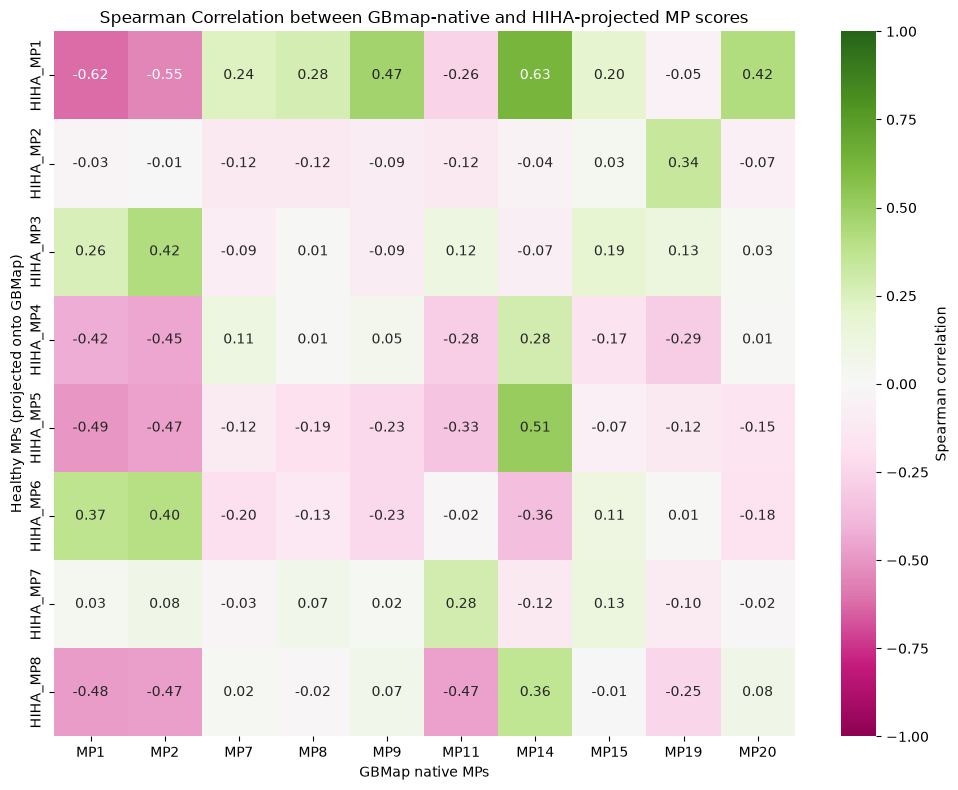

In [50]:
cross_corr_T = cross_corr.T

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cross_corr_T, cmap="PiYG", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", cbar_kws={"label": "Spearman correlation"}, ax=ax)
ax.set_ylabel("Healthy MPs (projected onto GBMap)")
ax.set_xlabel("GBMap native MPs")
plt.title("Spearman Correlation between GBmap-native and HIHA-projected MP scores")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "09_09_gbmap_native_vs_hiha_spearman.pdf"), bbox_inches="tight", dpi=300)
plt.show()

### Pearson Correlation

In [46]:

score_df = gbmap_adata.obs[native_score_cols + hiha_mp_cols].copy()
cross_corr_p = score_df.corr(method="pearson").loc[native_score_cols, hiha_mp_cols]
cross_corr_p.index = [c.replace("_score", "") for c in cross_corr_p.index]
cross_corr_p.columns = [c.replace("_score", "") for c in cross_corr_p.columns]



In [47]:
print(cross_corr_p.max())

HIHA_MP1    0.565569
HIHA_MP2    0.835793
HIHA_MP3    0.794344
HIHA_MP4    0.210239
HIHA_MP5    0.394666
HIHA_MP6    0.880165
HIHA_MP7    0.880428
HIHA_MP8    0.314974
dtype: float64


#### Pearson Heatmap

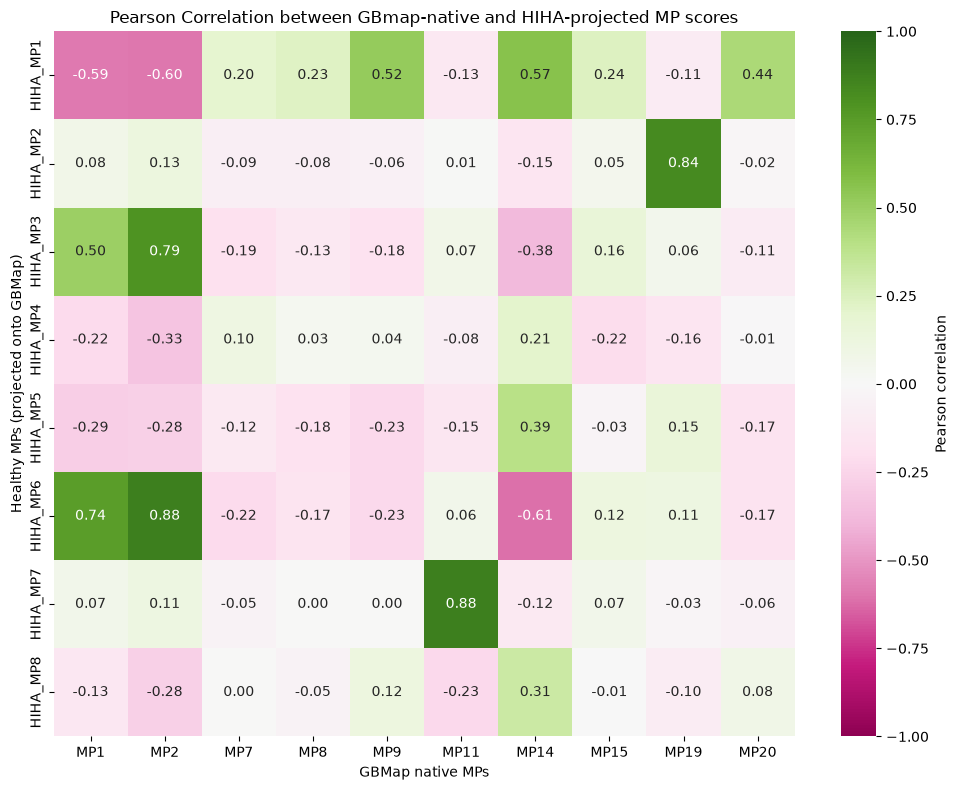

In [49]:
cross_corr_p_T = cross_corr_p.T

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cross_corr_p_T, cmap="PiYG", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_ylabel("Healthy MPs (projected onto GBMap)")
ax.set_xlabel("GBMap native MPs")
plt.title("Pearson Correlation between GBmap-native and HIHA-projected MP scores")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "09_09_gbmap_native_vs_hiha_pearson.pdf"), bbox_inches="tight", dpi=300)
plt.show()